## Getting started on Prolific

#### Launch your first survey via the API

### 1. Prolific Setup and Authentication
- Import required libraries
- Load API key from environment variables
- Authenticate and fetch your Prolific researcher ID

In [1]:
import os
import json
import yaml
import requests

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from prolific_helpers import (
    get_researcher_id,
    create_survey,
    create_study,
    publish_study,
    show_study_results,
    plot_survey_responses,
    plot_responses_by_generation,
    plot_responses_by_gender
)

In [3]:
# Load configuration
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [4]:
# Read API tokens for Jupyter Notebook
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
prolific_token = os.environ.get('PROLIFIC_API_TOKEN')
prolific_workspace = os.environ.get('PROLIFIC_WORKSPACE_ID')
prolific_project = os.environ.get('PROLIFIC_PROJECT_ID')

In [6]:
# Set up headers for authenticated requests to the Prolific API
headers = {
    "Authorization": f"Token {prolific_token}",
    "Content-Type": "application/json",
}

In [7]:
# Fetch your Prolific researcher ID
researcher_id, researcher_name = get_researcher_id(headers)
print(f"""
Authenticated.
Researcher ID: {researcher_id}
Researcher name: {researcher_name}
""")


Authenticated.
Researcher ID: 6866dccc753654157fe0da40
Researcher name: Viviana Marquez



### 2. Survey Creation

In [8]:
# Build survey question from config
question_text = config['survey']['question_text']
print(question_text)

Would you trust an AI system to help you make a decision?


In [9]:
# Create survey using helper function
survey_id = create_survey(headers, researcher_id, config['survey'])
print(f"Survey created with ID: {survey_id}")

Survey created with ID: 698128dfba8179d3536b4ca0


### 3. Study Publication
- Create the study with all parameters
- Publish it to make it available to participants
- Monitor study status and participant recruitment

In [10]:
# Prepare study configuration from config.yaml
study_config = {
    "name": config['study']['name'],
    "description": config['study']['description'],
    "privacy_notice": config['study']['privacy_notice'],
    "labels": config['study']['labels'],
    "reward": config['participants']['reward'],
    "participants": config['participants']['total_participants'],
    "estimated_time": config['participants']['estimated_time'],
    "max_time": config['participants']['max_time'],
    "device_compatibility": config['device_compatibility']
}

# Create study using helper function
study_id = create_study(headers, survey_id, study_config, prolific_project)
print(f"Study created with ID: {study_id}")
print(f"https://app.prolific.com/researcher/workspaces/studies/{study_id}")

Study created with ID: 698128e20587dfee678c0380
https://app.prolific.com/researcher/workspaces/studies/698128e20587dfee678c0380


In [11]:
# Publish study using helper function
status_code = publish_study(headers, study_id)
print(f"Study published with status code: {status_code}")

Study published with status code: 200


# RESULTS
- Monitor participant submissions
- Export results in CSV format
- Load data into pandas DataFrame for analysis
- Calculate completion times and response statistics

In [32]:
# Fetch and display study results using helper function and configured timezone
df = show_study_results(study_id, headers, config['timezone'])

✅ Study Name: One mutiple choice question about AI
📊 Status: AWAITING REVIEW
👥 Total Places: 20
📩 Total Submissions: 20
⏳ Created at: 02 Feb 2026, 02:49 PM PST
🕒 Last Response At: 02 Feb 2026, 02:56 PM PST
⏱️ Time Lapsed: 7 minutes


In [34]:
df.head()

,Submission id,Participant id,Status,Custom study tncs accepted at,Started at,Completed at,Reviewed at,Archived at,Time taken,Completion code,...,Age,Sex,Ethnicity simplified,Country of birth,Country of residence,Nationality,Language,Student status,Employment status,Would you trust an AI system to help you make a decision?
0,69812a2d57ea59c91568ac08,697ceddbe9388bbd3d4369af,AWAITING REVIEW,Not Applicable,2026-02-02T22:50:24.357000Z,2026-02-02T22:50:31.198000Z,NaN,2026-02-02T22:50:31.541878Z,7,NOCODE,...,28,Male,White,United States,United States,United States,English,No,Due to start a new job within the next month,Yes
1,69812a2e80c8e1faca14d6c8,5a89c5100f1bce0001224361,AWAITING REVIEW,Not Applicable,2026-02-02T22:50:24.814000Z,2026-02-02T22:51:49.290000Z,NaN,2026-02-02T22:51:49.651013Z,85,NOCODE,...,60,Female,White,United States,United States,United States,English,No,Full-Time,Yes
2,69812a3a6df8b1aae28326aa,61112fb91e6eb028aa1ba59b,AWAITING REVIEW,Not Applicable,2026-02-02T22:50:36.241000Z,2026-02-02T22:50:43.284000Z,NaN,2026-02-02T22:50:43.624498Z,8,NOCODE,...,39,Female,White,United Kingdom,United Kingdom,United Kingdom,English,No,Part-Time,Yes
3,69812a3cb0553862507165f7,654e37a130d94b47675dcebe,AWAITING REVIEW,Not Applicable,2026-02-02T22:50:37.596000Z,2026-02-02T22:50:42.642000Z,NaN,2026-02-02T22:50:43.038993Z,6,NOCODE,...,35,Male,White,United Kingdom,United Kingdom,United Kingdom,English,No,Full-Time,Yes
4,69812a3e39d6a043d039ee8c,697a8391f231881bba554954,AWAITING REVIEW,Not Applicable,2026-02-02T22:50:39.841000Z,2026-02-02T22:51:11.557000Z,NaN,2026-02-02T22:51:11.903212Z,32,NOCODE,...,22,Male,White,Belgium,Belgium,Belgium,Dutch,Yes,Part-Time,No


In [17]:
df.columns

Index(['Submission id', 'Participant id', 'Status',
       'Custom study tncs accepted at', 'Started at', 'Completed at',
       'Reviewed at', 'Archived at', 'Time taken', 'Completion code',
       'Total approvals', 'Age', 'Sex', 'Ethnicity simplified',
       'Country of birth', 'Country of residence', 'Nationality', 'Language',
       'Student status', 'Employment status',
       'Would you trust an AI system to help you make a decision?'],
      dtype='object')

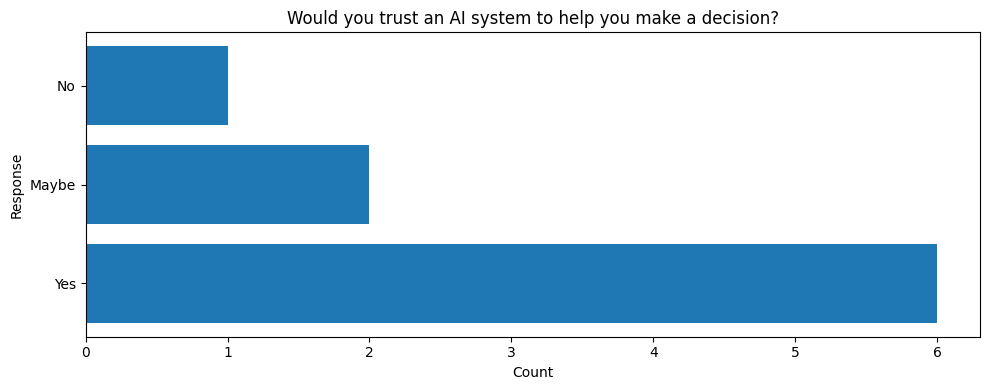

In [18]:
# Plot survey responses using helper function
question_column = config['survey']['question_text']
fig, ax = plot_survey_responses(df, question_column)
plt.show()

### Results by Generation
Breakdown of responses by age generation with labeled age ranges

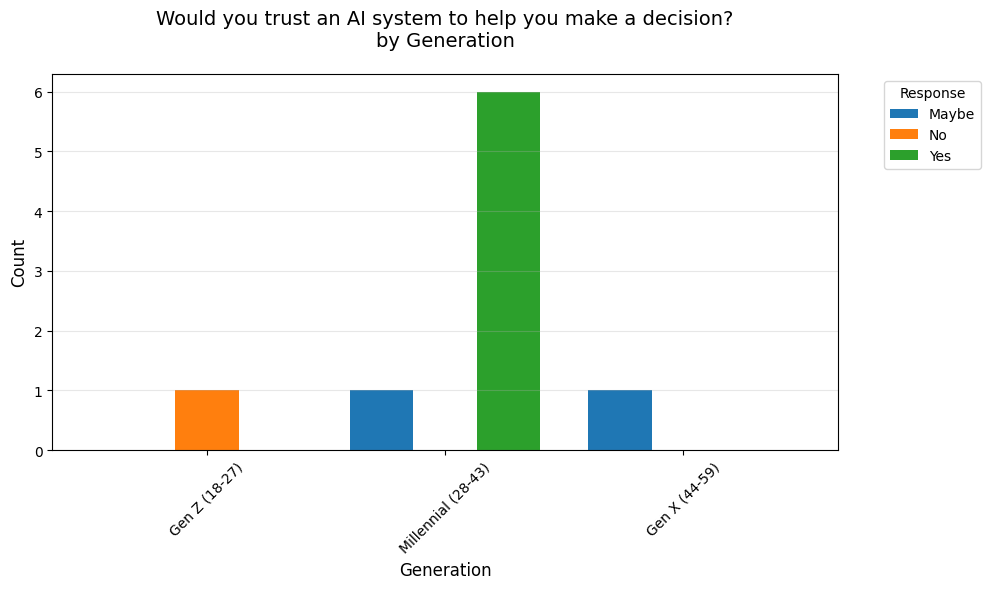

In [19]:
# Plot responses by generation
fig, ax = plot_responses_by_generation(df, question_column)
plt.show()

### Results by Gender
Breakdown of responses by gender/sex

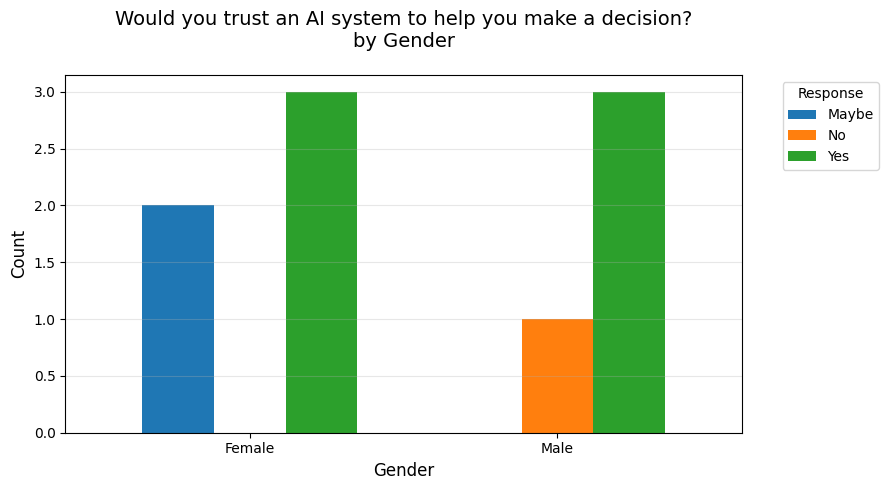

In [20]:
# Plot responses by gender
fig, ax = plot_responses_by_gender(df, question_column)
plt.show()

# Questions?